# Exploratory data analysis — 22-commodity panel

Statistical exploration of aligned daily prices and log-returns. No external narratives; outputs feed `data/market_events.csv` for downstream work.


In [1]:
# --- Paths & parameters (edit here) ---
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

DATA_DIR = Path("data")
PRICES_PATH = DATA_DIR / "prices.csv"
RETURNS_PATH = DATA_DIR / "returns.csv"
EVENTS_PATH = DATA_DIR / "market_events.csv"

RECENT_WINDOW_DAYS = 126
ROLLING_VOL_WINDOW = 21
TRADING_DAYS_PER_YEAR = 252
SIGMA_EVENT_THRESHOLD = 3.0
VOL_SPIKE_RATIO = 1.5
CORR_BREAK_THRESHOLD = 0.35

SECTOR_MAP = {
    "Brent": "Energy",
    "WTI": "Energy",
    "NaturalGas": "Energy",
    "Gasoline": "Energy",
    "Diesel": "Energy",
    "Gold": "Metals",
    "Silver": "Metals",
    "Copper": "Metals",
    "Aluminium": "Metals",
    "Nickel": "Metals",
    "Zinc": "Metals",
    "Coffee": "Agriculture",
    "Corn": "Agriculture",
    "Cotton": "Agriculture",
    "LeanHogs": "Agriculture",
    "LiveCattle": "Agriculture",
    "Sugar": "Agriculture",
    "Soybeans": "Agriculture",
    "SoybeanMeal": "Agriculture",
    "SoybeanOil": "Agriculture",
    "HRWWheat": "Agriculture",
    "Wheat": "Agriculture",
}

SECTOR_ORDER = ["Energy", "Metals", "Agriculture"]
COMMODITIES = list(SECTOR_MAP.keys())

def sector_sort_key(name):
    return (SECTOR_ORDER.index(SECTOR_MAP[name]), COMMODITIES.index(name))

COMMODITIES_ORDERED = sorted(COMMODITIES, key=sector_sort_key)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline


In [2]:
# --- Load panels ---
prices = pd.read_csv(PRICES_PATH, parse_dates=["date"]).set_index("date").sort_index()
returns_z = pd.read_csv(RETURNS_PATH, parse_dates=["date"]).set_index("date").sort_index()

# Raw log-returns from prices (volatility, sigma events, distributional stats)
log_returns = np.log(prices / prices.shift(1)).dropna(how="any")
returns_z = returns_z.reindex(log_returns.index)

recent_start = log_returns.index[-RECENT_WINDOW_DAYS]
recent_end = log_returns.index[-1]
recent_mask = log_returns.index >= recent_start

print(f"Data start: {prices.index.min().date()}")
print(f"Data end:   {prices.index.max().date()}")
print(f"Row count (returns): {len(log_returns):,}")
print(f"Recent window ({RECENT_WINDOW_DAYS} trading days): {recent_start.date()} → {recent_end.date()}")


Data start: 2005-10-04
Data end:   2026-05-29
Row count (returns): 5,075
Recent window (126 trading days): 2025-11-21 → 2026-05-29


## 1. Integrity & overview


In [3]:
print("Prices shape:", prices.shape)
print("Returns file shape:", returns_z.shape)
print("Raw log-returns shape:", log_returns.shape)
print("Missing values — prices:", int(prices.isna().sum().sum()))
print("Missing values — log_returns:", int(log_returns.isna().sum().sum()))

# returns.csv stores z-scored log-returns; verify against raw panel
raw_mean = log_returns.mean()
raw_std = log_returns.std(ddof=0)
reconstructed_z = log_returns.sub(raw_mean).div(raw_std)
max_z_diff = (reconstructed_z - returns_z).abs().max().max()
print(f"Max |reconstructed z − returns.csv|: {max_z_diff:.2e}")

summary = log_returns.agg(["mean", "std", "skew", "kurtosis"]).T
summary.columns = ["mean", "std", "skew", "kurtosis"]
summary.insert(0, "sector", summary.index.map(SECTOR_MAP))
summary = summary.loc[COMMODITIES_ORDERED]
display(summary.round(6))

recent_summary = log_returns.loc[recent_mask].agg(["mean", "std", "skew", "kurtosis"]).T
recent_summary.columns = [f"recent_{c}" for c in recent_summary.columns]
dist_compare = summary.drop(columns="sector").join(recent_summary)
dist_compare.insert(0, "sector", dist_compare.index.map(SECTOR_MAP))
print("\nFull-sample vs recent-window moments:")
display(dist_compare.round(6))

# WTI April-2020 negative-price guard: no 2020-04-20/21 rows, no artificial spike
wti_april = log_returns.loc["2020-04-01":"2020-04-30", "WTI"]
print("\nWTI April 2020 max |log-return|:", round(wti_april.abs().max(), 4))
print("2020-04-20 in return index:", pd.Timestamp("2020-04-20") in log_returns.index)
print("2020-04-21 in return index:", pd.Timestamp("2020-04-21") in log_returns.index)


Prices shape: (5078, 22)
Returns file shape: (5075, 22)
Raw log-returns shape: (5075, 22)
Missing values — prices: 1
Missing values — log_returns: 0
Max |reconstructed z − returns.csv|: 2.84e-14


,sector,mean,std,skew,kurtosis
Brent,Energy,0.000154,0.023534,-0.595927,10.206334
WTI,Energy,0.000180,0.026963,-0.087179,18.207668
NaturalGas,Energy,-0.000296,0.038779,-0.494631,21.196996
Gasoline,Energy,0.000169,0.026553,-0.886744,18.324298
Diesel,Energy,0.000162,0.022913,-0.664149,7.714657
Gold,Metals,0.000451,0.011801,-0.539570,6.892444
Silver,Metals,0.000463,0.022506,-1.508965,20.595484
Copper,Metals,0.000263,0.017863,-0.599898,11.009322
Aluminium,Metals,0.000140,0.014779,-0.245571,3.412251
Nickel,Metals,0.000068,0.025836,1.009527,39.400254



Full-sample vs recent-window moments:


,sector,mean,std,skew,kurtosis,recent_mean,recent_std,recent_skew,recent_kurtosis
Brent,Energy,0.000154,0.023534,-0.595927,10.206334,0.002962,0.039504,-1.329307,3.701019
WTI,Energy,0.000180,0.026963,-0.087179,18.207668,0.003096,0.040820,-1.071873,4.416843
NaturalGas,Energy,-0.000296,0.038779,-0.494631,21.196996,-0.002440,0.083891,-3.454918,28.832891
Gasoline,Energy,0.000169,0.026553,-0.886744,18.324298,0.003877,0.031544,-0.179346,2.713303
Diesel,Energy,0.000162,0.022913,-0.664149,7.714657,0.002650,0.043135,-0.901875,2.505167
Gold,Metals,0.000451,0.011801,-0.539570,6.892444,0.000923,0.020425,-1.758768,9.874763
Silver,Metals,0.000463,0.022506,-1.508965,20.595484,0.003262,0.054910,-2.671200,17.377607
Copper,Metals,0.000263,0.017863,-0.599898,11.009322,0.001996,0.018574,-0.014428,0.394989
Aluminium,Metals,0.000140,0.014779,-0.245571,3.412251,0.002264,0.014948,0.111037,0.971934
Nickel,Metals,0.000068,0.025836,1.009527,39.400254,0.002184,0.020167,0.349289,3.356931



WTI April 2020 max |log-return|: 0.3196
2020-04-20 in return index: False
2020-04-21 in return index: False


**Takeaway:** The panel is complete on the return sample with per-commodity moments comparable to a descriptive Table 1; the April-2020 WTI negative-price dates were excluded, so no spurious return spike remains.


## 2. History


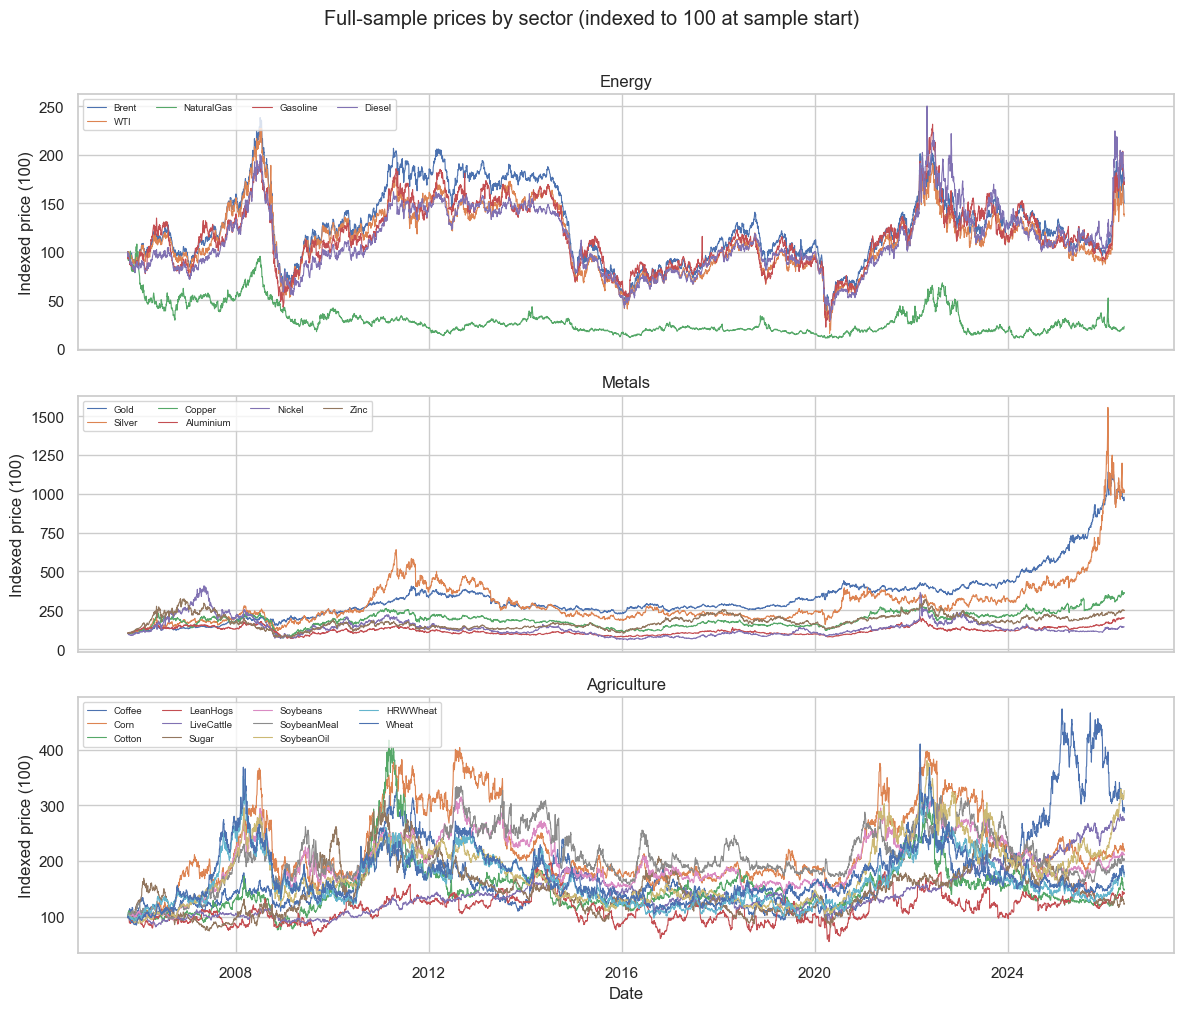

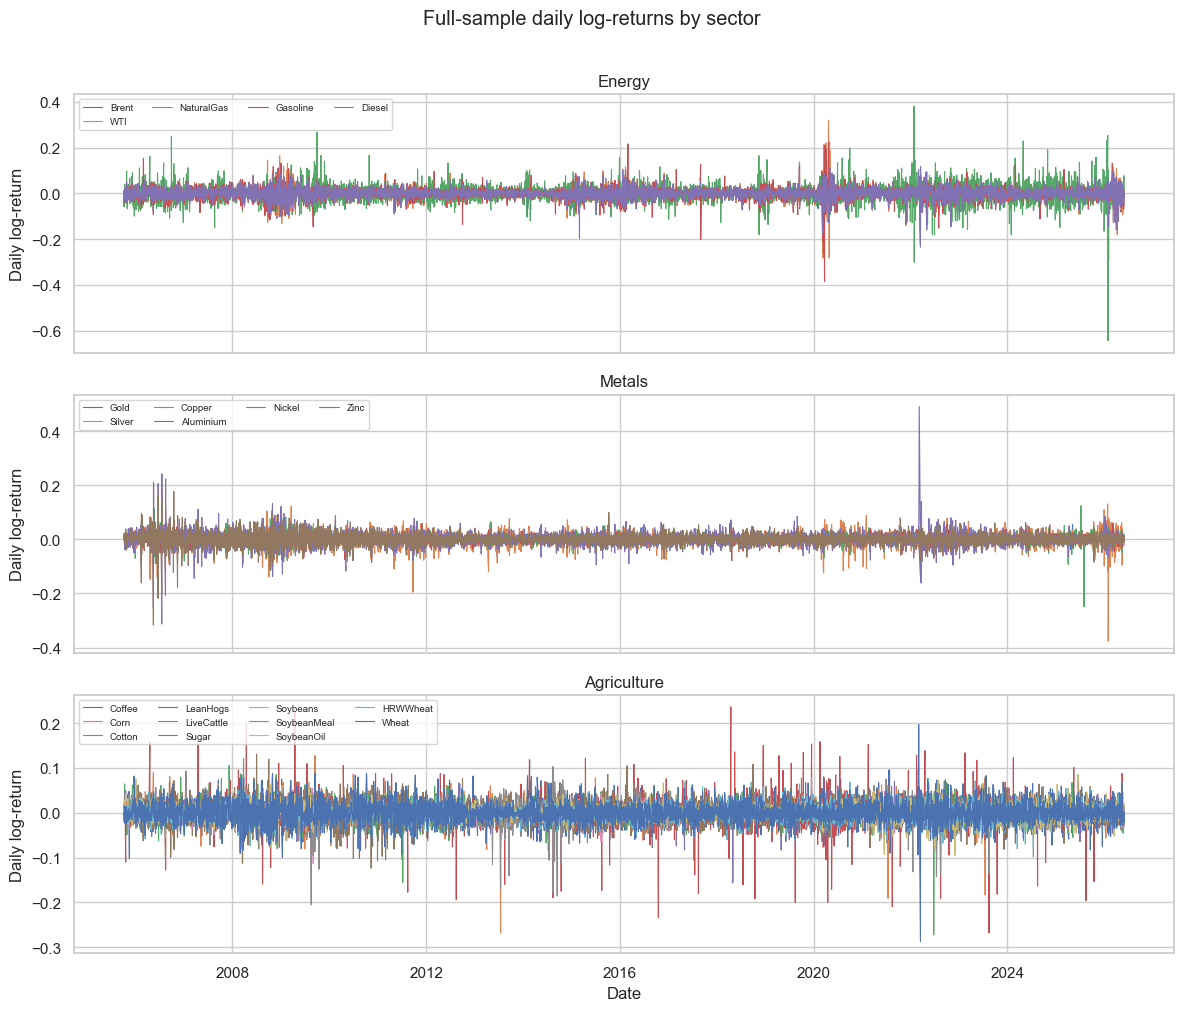

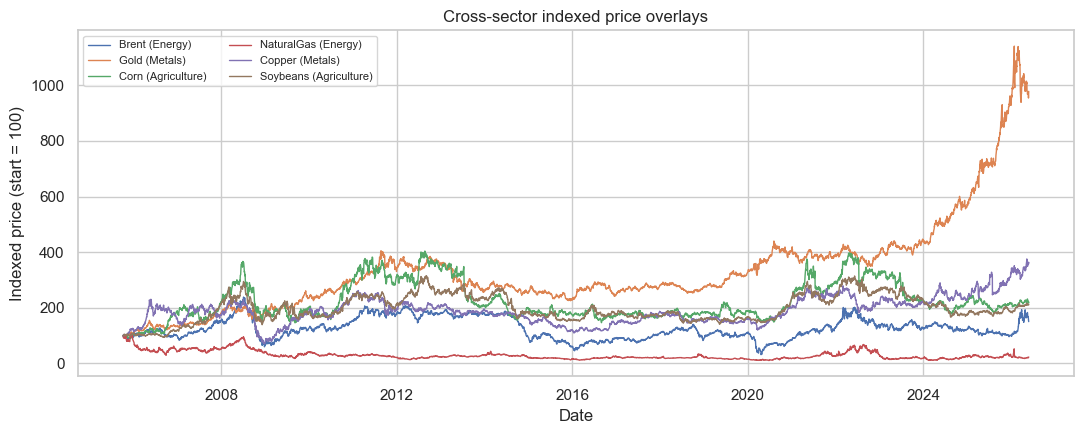

In [4]:
def plot_sector_multiples(data, ylabel, title, indexed=False):
    fig, axes = plt.subplots(len(SECTOR_ORDER), 1, figsize=(12, 10), sharex=True)
    for ax, sector in zip(axes, SECTOR_ORDER):
        cols = [c for c in COMMODITIES_ORDERED if SECTOR_MAP[c] == sector]
        for c in cols:
            series = data[c]
            if indexed:
                series = series / series.iloc[0] * 100
            ax.plot(series.index, series.values, lw=0.8, label=c)
        ax.set_ylabel(ylabel)
        ax.set_title(sector)
        ax.legend(ncol=4, fontsize=7, loc="upper left")
    axes[-1].set_xlabel("Date")
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

plot_sector_multiples(prices, "Indexed price (100)", "Full-sample prices by sector (indexed to 100 at sample start)", indexed=True)
plot_sector_multiples(log_returns, "Daily log-return", "Full-sample daily log-returns by sector")

overlay_specs = [
    ("Brent", "Energy"),
    ("Gold", "Metals"),
    ("Corn", "Agriculture"),
    ("NaturalGas", "Energy"),
    ("Copper", "Metals"),
    ("Soybeans", "Agriculture"),
]
fig, ax = plt.subplots(figsize=(11, 4.5))
for c, sector in overlay_specs:
    idx = prices[c] / prices[c].iloc[0] * 100
    ax.plot(idx.index, idx.values, lw=1.0, label=f"{c} ({sector})")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed price (start = 100)")
ax.set_title("Cross-sector indexed price overlays")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


**Takeaway:** Long-run price and return paths cluster by sector, while cross-sector overlays show periods when energy, metals, and agriculture diverge.


## 3. Volatility


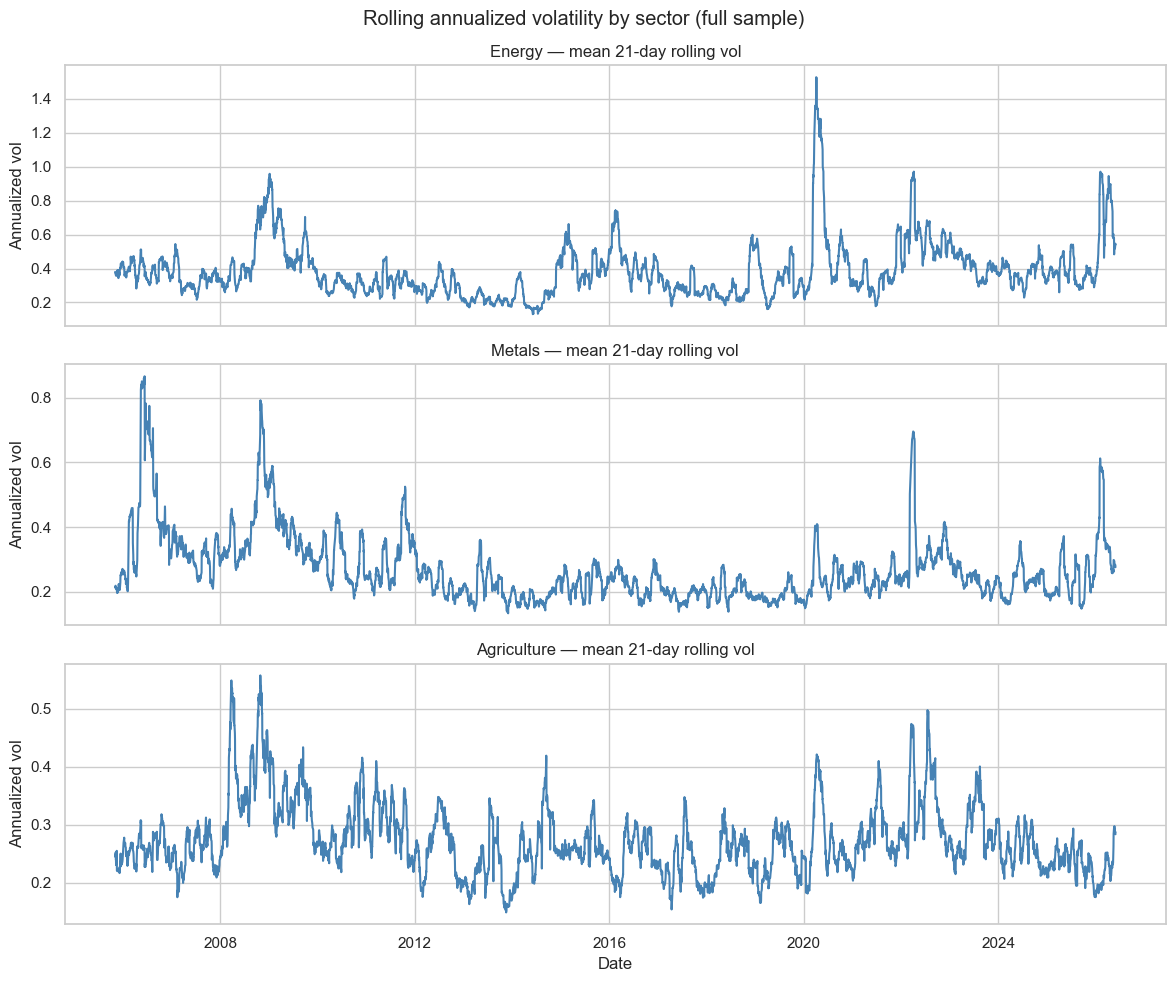

,sector,full_sample_ann_vol,recent_ann_vol,ratio_recent_to_full
Silver,Metals,0.3572,0.8682,2.4304
NaturalGas,Energy,0.6155,1.3264,2.1549
Diesel,Energy,0.3637,0.6820,1.8752
Gold,Metals,0.1873,0.3229,1.7240
Brent,Energy,0.3736,0.6246,1.6721
WTI,Energy,0.4280,0.6454,1.5080
Gasoline,Energy,0.4215,0.4987,1.1833
Copper,Metals,0.2835,0.2937,1.0358
Aluminium,Metals,0.2346,0.2363,1.0075
Coffee,Agriculture,0.3303,0.3269,0.9898


Top 5 volatility increases (recent vs full sample):


,sector,full_sample_ann_vol,recent_ann_vol,ratio_recent_to_full
Silver,Metals,0.357232,0.868199,2.430351
NaturalGas,Energy,0.615540,1.326432,2.154907
Diesel,Energy,0.363704,0.682021,1.875208
Gold,Metals,0.187322,0.322946,1.724015
Brent,Energy,0.373554,0.624614,1.672086


In [5]:
def annualized_vol(returns, window=ROLLING_VOL_WINDOW):
    return returns.rolling(window).std() * np.sqrt(TRADING_DAYS_PER_YEAR)

roll_vol = annualized_vol(log_returns)

fig, axes = plt.subplots(len(SECTOR_ORDER), 1, figsize=(12, 10), sharex=True)
for ax, sector in zip(axes, SECTOR_ORDER):
    cols = [c for c in COMMODITIES_ORDERED if SECTOR_MAP[c] == sector]
    sector_vol = roll_vol[cols].mean(axis=1)
    ax.plot(sector_vol.index, sector_vol.values, color="steelblue")
    ax.set_ylabel("Annualized vol")
    ax.set_title(f"{sector} — mean {ROLLING_VOL_WINDOW}-day rolling vol")
axes[-1].set_xlabel("Date")
fig.suptitle("Rolling annualized volatility by sector (full sample)")
plt.tight_layout()
plt.show()

full_vol = log_returns.std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)
recent_vol = log_returns.loc[recent_mask].std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)
vol_ratio = recent_vol / full_vol

vol_table = pd.DataFrame({
    "sector": vol_ratio.index.map(SECTOR_MAP),
    "full_sample_ann_vol": full_vol,
    "recent_ann_vol": recent_vol,
    "ratio_recent_to_full": vol_ratio,
})
vol_table = vol_table.sort_values("ratio_recent_to_full", ascending=False)
display(vol_table.round(4))

print("Top 5 volatility increases (recent vs full sample):")
display(vol_table.head(5))


**Takeaway:** Commodities with the highest recent-to-full volatility ratios are trading materially above their long-run risk level.


## 4. Correlation / co-movement


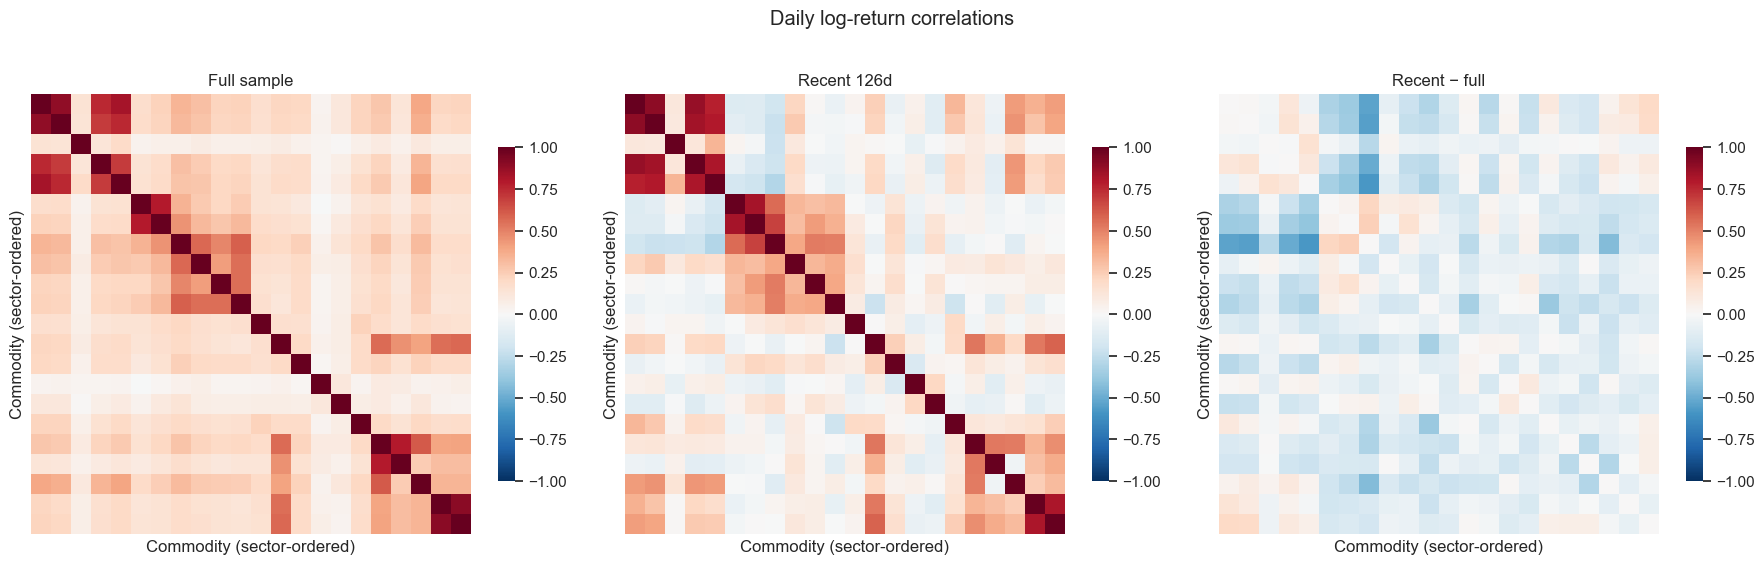

In [6]:
def sector_ordered_corr(df):
    ordered = [c for c in COMMODITIES_ORDERED if c in df.columns]
    return df[ordered].corr()

corr_full = sector_ordered_corr(log_returns)
corr_recent = sector_ordered_corr(log_returns.loc[recent_mask])
corr_diff = corr_recent - corr_full

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, mat, title in zip(
    axes,
    [corr_full, corr_recent, corr_diff],
    ["Full sample", f"Recent {RECENT_WINDOW_DAYS}d", "Recent − full"],
):
    sns.heatmap(
        mat, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
        cbar_kws={"shrink": 0.7}, xticklabels=False, yticklabels=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Commodity (sector-ordered)")
    ax.set_ylabel("Commodity (sector-ordered)")
plt.suptitle("Daily log-return correlations", y=1.02)
plt.tight_layout()
plt.show()


**Takeaway:** The difference heatmap flags commodity pairs whose co-movement changed most between the recent window and the full history.


## 5. Recent deep dive & event detection


Cumulative log-return over recent window (2025-11-21 → 2026-05-29):


,sector,cumulative_log_return
Gasoline,Energy,0.4885
SoybeanOil,Agriculture,0.4280
Silver,Metals,0.4111
WTI,Energy,0.3901
Brent,Energy,0.3732
Diesel,Energy,0.3338
Aluminium,Metals,0.2853
Nickel,Metals,0.2752
Copper,Metals,0.2515
HRWWheat,Agriculture,0.2496



Equal-weight sector cumulative log-return (recent window):


,cumulative_log_return
Energy,0.2556
Metals,0.2466
Agriculture,0.0956


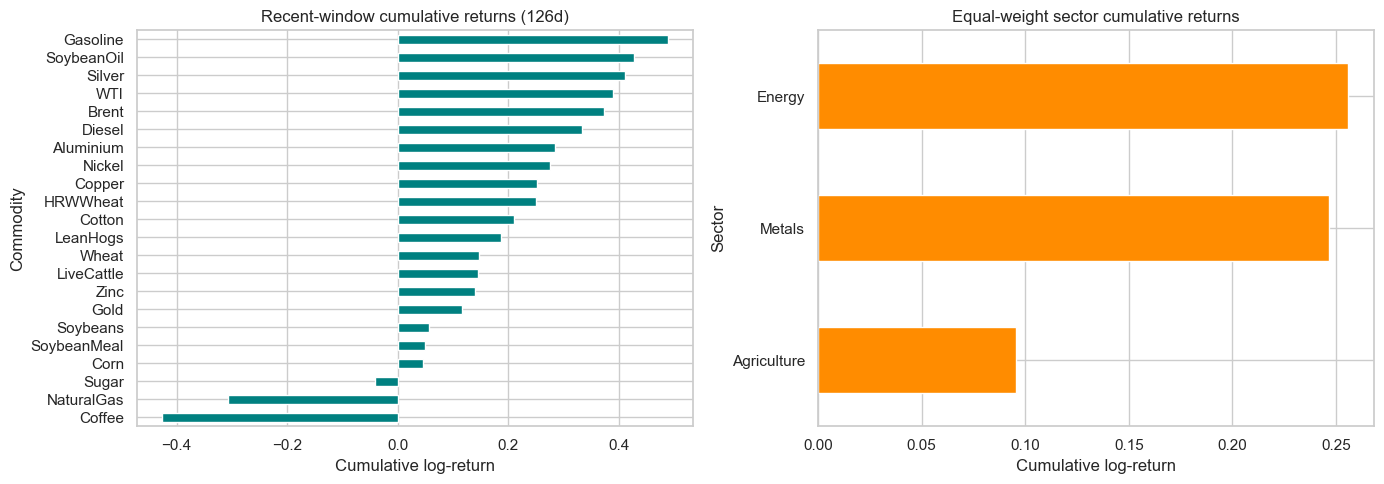


Wrote 84 events → data/market_events.csv


,date,commodity,sector,return,sigma_level,signature
0,2025-11-24,LiveCattle,Agriculture,-0.034392,-3.05,−3.1σ daily move
1,2025-12-17,Coffee,Agriculture,-0.074980,-3.60,−3.6σ daily move
2,2025-12-30,NaturalGas,Energy,-0.165523,-4.27,−4.3σ daily move
3,2025-12-30,Silver,Metals,0.109234,4.85,+4.9σ daily move
4,2025-12-31,Silver,Metals,-0.098597,-4.38,−4.4σ daily move
...,...,...,...,...,...,...
79,2026-05-29,Silver,Metals,NaN,NaN,vol spike (2.43× full-sample)
80,2026-05-29,WTI,Energy,NaN,NaN,vol spike (1.51× full-sample)
81,2026-05-29,WTI/Copper,Energy-Metals,-0.549562,NaN,correlation break (Δρ=-0.55)
82,2026-05-29,WTI/Silver,Energy-Metals,-0.351607,NaN,correlation break (Δρ=-0.35)


In [7]:
recent_lr = log_returns.loc[recent_mask]

cum_recent = recent_lr.sum().sort_values(ascending=False)
cum_df = cum_recent.to_frame("cumulative_log_return")
cum_df.insert(0, "sector", cum_df.index.map(SECTOR_MAP))
print(f"Cumulative log-return over recent window ({recent_start.date()} → {recent_end.date()}):")
display(cum_df.sort_values("cumulative_log_return", ascending=False).round(4))

sector_cum = {}
for sector in SECTOR_ORDER:
    cols = [c for c in COMMODITIES if SECTOR_MAP[c] == sector]
    sector_cum[sector] = recent_lr[cols].mean(axis=1).sum()
sector_cum = pd.Series(sector_cum).reindex(SECTOR_ORDER).sort_values(ascending=False)
print("\nEqual-weight sector cumulative log-return (recent window):")
display(sector_cum.to_frame("cumulative_log_return").round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cum_recent.sort_values().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_xlabel("Cumulative log-return")
axes[0].set_ylabel("Commodity")
axes[0].set_title(f"Recent-window cumulative returns ({RECENT_WINDOW_DAYS}d)")
sector_cum.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_xlabel("Cumulative log-return")
axes[1].set_ylabel("Sector")
axes[1].set_title("Equal-weight sector cumulative returns")
plt.tight_layout()
plt.show()

# --- Detect events & write handoff file ---
full_sigma = log_returns.std(ddof=0)
events = []

for date, row in recent_lr.iterrows():
    for commodity in COMMODITIES:
        r = row[commodity]
        sig = full_sigma[commodity]
        if sig == 0 or np.isnan(r):
            continue
        z = r / sig
        if abs(z) >= SIGMA_EVENT_THRESHOLD:
            sign = "−" if z < 0 else "+"
            events.append({
                "date": date.date().isoformat(),
                "commodity": commodity,
                "sector": SECTOR_MAP[commodity],
                "return": r,
                "sigma_level": round(z, 2),
                "signature": f"{sign}{abs(z):.1f}σ daily move",
            })

for commodity in COMMODITIES:
    ratio = vol_ratio[commodity]
    if ratio >= VOL_SPIKE_RATIO:
        events.append({
            "date": recent_end.date().isoformat(),
            "commodity": commodity,
            "sector": SECTOR_MAP[commodity],
            "return": np.nan,
            "sigma_level": np.nan,
            "signature": f"vol spike ({ratio:.2f}× full-sample)",
        })

cols = list(corr_full.columns)
for i, c1 in enumerate(cols):
    for c2 in cols[i + 1:]:
        delta = corr_diff.loc[c1, c2]
        if abs(delta) >= CORR_BREAK_THRESHOLD:
            events.append({
                "date": recent_end.date().isoformat(),
                "commodity": f"{c1}/{c2}",
                "sector": f"{SECTOR_MAP[c1]}-{SECTOR_MAP[c2]}",
                "return": delta,
                "sigma_level": np.nan,
                "signature": f"correlation break (Δρ={delta:+.2f})",
            })

events_df = pd.DataFrame(events, columns=["date", "commodity", "sector", "return", "sigma_level", "signature"])
if not events_df.empty:
    events_df = events_df.sort_values(["date", "commodity"]).reset_index(drop=True)

events_df.to_csv(EVENTS_PATH, index=False)
print(f"\nWrote {len(events_df)} events → {EVENTS_PATH}")
display(events_df)


**Takeaway:** Extreme daily moves (|r| > 3σ vs full-sample σ), elevated recent volatility, and large correlation shifts are exported to `data/market_events.csv` for downstream analysis.
